#Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import RMSprop, Adam, SGD, Nadam, AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import tensorflow as tf

import json

import pickle

from itertools import combinations



#Ruta para guardar/importar archivos

In [2]:
ruta='/Users/antoniot/Desktop/red_uno_lstm/'

#Importar base de datos

In [3]:
df=pd.read_csv('/Users/antoniot/Desktop/red_uno_lstm/base_datos.csv')
df

,country,date,GDP_cnstn,GDP_growth,GDP_cnstn_usd,GDP_pp_usd,GDP_pp_LCU,Inflatn,forgn_invst,forgn_invst_gdp,Fin_consum,Fin_consum_govern,Ext_balnce_g_s,Fin_consum_hous,Unmploy,Labor_part,GDP_usd
0,Australia,2022,2.552248e+12,4.253046,1.592358e+12,61200.458896,98092.754060,7.199544,6.870942e+10,4.052153,71.071701,22.017954,5.228418,49.053747,3.728,66.846,1.695628e+12
1,Australia,2021,2.448128e+12,2.006948,1.527397e+12,59465.535671,95312.000446,3.060670,3.145306e+10,2.015424,73.318371,22.366947,3.801393,50.951424,5.022,66.056,1.560617e+12
2,Australia,2020,2.399962e+12,-0.133532,1.497346e+12,58377.767052,93568.513198,1.865834,1.797684e+10,1.348260,74.278610,21.813861,3.376511,52.464749,6.394,64.980,1.333336e+12
3,Australia,2019,2.403171e+12,2.194017,1.499348e+12,59181.299790,94856.424118,3.476600,3.874513e+10,2.770776,74.579592,20.289384,2.123277,54.290208,5.143,66.052,1.398350e+12
4,Australia,2018,2.351577e+12,2.874170,1.467158e+12,58772.706315,94201.526099,1.846176,6.068664e+10,4.234508,75.393593,19.942302,0.051922,55.451291,5.345,65.746,1.433145e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
675,United States,1987,9.627608e+12,3.454630,8.849219e+12,36523.404486,39736.051302,2.477388,6.323500e+10,1.302414,79.361511,16.001207,-2.981742,63.360304,6.200,65.600,4.855215e+12
676,United States,1986,9.306116e+12,3.462655,8.553720e+12,35620.759359,38754.008320,2.013893,3.094600e+10,0.675731,79.138843,16.114595,-2.879468,63.024248,7.000,65.300,4.579631e+12
677,United States,1985,8.994662e+12,4.169575,8.267447e+12,34748.266874,37804.770246,3.162525,9.630000e+09,0.221942,78.439421,15.917109,-2.627761,62.522312,7.200,64.800,4.338979e+12
678,United States,1984,8.634635e+12,7.236453,7.936527e+12,33654.307930,36614.585231,3.607879,2.523000e+10,0.624874,77.448433,15.720377,-2.544251,61.728056,7.500,64.400,4.037613e+12


#Preprocesamiento de la base

In [4]:
countries = df["country"].unique()
print(countries.shape)
countries

(17,)


<StringArray>
[           'Australia',              'Austria',              'Belgium',
               'Canada',              'Germany',              'Denmark',
                'Spain',               'France',       'United Kingdom',
               'Greece', 'Hong Kong SAR, China',              'Ireland',
                'Italy',                'Japan',          'Korea, Rep.',
               'Norway',        'United States']
Length: 17, dtype: str

In [5]:
#@title Funcion
def preparar_pipeline(vars_keep, input_length, output_length):

    import numpy as np
    from sklearn.preprocessing import MinMaxScaler

    col_ref = vars_keep.index('GDP_cnstn_usd')

    for c in countries:
      name = c.replace(" ", "_")
      globals()[f"base_{name}"] = df[df["country"] == c]

    for name in globals():
      if name.startswith("base_"):
          globals()[name] = globals()[name].sort_values(by="date")

    # Años
    ano_ini_entre = 1983
    ano_fin_entre = 2010
    ano_ini_val = 2011
    ano_fin_val = 2016
    ano_ini_test = 2017
    ano_fin_test = 2022

    anos_entre = ano_fin_entre - ano_ini_entre + 1
    anos_vali = ano_fin_val - ano_ini_val + 1
    anos_test = ano_fin_test - ano_ini_test + 1

    # Selección de columnas
    for name in globals():
        if name.startswith("base_"):
            globals()[name] = globals()[name][vars_keep]

    # ---------------- TRAIN ----------------
    for name in list(globals().keys()):
        if name.startswith("base_"):

            x_train, y_train = [], []
            array = globals()[name].to_numpy()

            for i in range(anos_entre - input_length - output_length + 1):

                x_train.append(array[i:i+input_length])

                y_train.append(
                    array[i+input_length:i+input_length+output_length, -1]
                    .reshape(output_length, 1)
                )

            clean = name.replace("base_", "")

            globals()[f"x_train_{clean}"] = np.array(x_train)
            globals()[f"y_train_{clean}"] = np.array(y_train)

    # ---------------- VALID ----------------
    for name in list(globals().keys()):
        if name.startswith("base_"):

            x_val, y_val = [], []
            array = globals()[name].to_numpy()

            for i in range(
                anos_entre - input_length,
                anos_entre + anos_vali - output_length - input_length + 1
            ):

                x_val.append(array[i:i+input_length])

                y_val.append(
                    array[i+input_length:i+input_length+output_length, -1]
                    .reshape(output_length, 1)
                )

            clean = name.replace("base_", "")

            globals()[f"x_val_{clean}"] = np.array(x_val)
            globals()[f"y_val_{clean}"] = np.array(y_val)

    # ---------------- TEST ----------------
    for name in list(globals().keys()):
        if name.startswith("base_"):

            x_test, y_test = [], []
            array = globals()[name].to_numpy()

            for i in range(
                anos_entre + anos_vali - input_length,
                anos_entre + anos_vali + anos_test - output_length - input_length + 1
            ):

                x_test.append(array[i:i+input_length])

                y_test.append(
                    array[i+input_length:i+input_length+output_length, -1]
                    .reshape(output_length, 1)
                )

            clean = name.replace("base_", "")

            globals()[f"x_test_{clean}"] = np.array(x_test)
            globals()[f"y_test_{clean}"] = np.array(y_test)

    # ---------------- SCALERS ----------------
    for name in list(globals().keys()):
        if name.startswith("base_"):
            clean = name.replace("base_", "")
            globals()[f"scaler_{clean}"] = [
                MinMaxScaler(feature_range=(-1, 1))
                for _ in range(len(vars_keep))
            ]

    # ---------------- CREAR ARRAYS VACÍOS ----------------
    for name in list(globals().keys()):

        if name.startswith("x_train"):
            clean = name.replace("x_train", "")
            globals()[f"x_tr{clean}"] = np.zeros(globals()[name].shape)

        if name.startswith("y_train"):
            clean = name.replace("y_train", "")
            globals()[f"y_tr{clean}"] = np.zeros(globals()[name].shape)

        if name.startswith("x_val"):
            clean = name.replace("x_val", "")
            globals()[f"x_vl{clean}"] = np.zeros(globals()[name].shape)

        if name.startswith("y_val"):
            clean = name.replace("y_val", "")
            globals()[f"y_vl{clean}"] = np.zeros(globals()[name].shape)

        if name.startswith("x_test"):
            clean = name.replace("x_test", "")
            globals()[f"x_tst{clean}"] = np.zeros(globals()[name].shape)

        if name.startswith("y_test"):
            clean = name.replace("y_test", "")
            globals()[f"y_tst{clean}"] = np.zeros(globals()[name].shape)

    # ---------------- ESCALADO X TRAIN ----------------
    for name in list(globals().keys()):
        if name.startswith("x_train_"):

            clean = name.replace("x_train_", "")
            X = globals()[name]
            scalers = globals()[f"scaler_{clean}"]

            for i in range(len(vars_keep)):

                data = X[:, :, i].reshape(-1, 1)
                scaled = scalers[i].fit_transform(data)

                globals()[f"x_tr_{clean}"][:, :, i] = scaled.reshape(
                    X[:, :, i].shape
                )

    # ---------------- ESCALADO X VALID ----------------
    for name in list(globals().keys()):
        if name.startswith("x_val_"):

            clean = name.replace("x_val_", "")
            X = globals()[name]
            scalers = globals()[f"scaler_{clean}"]

            for i in range(len(vars_keep)):

                data = X[:, :, i].reshape(-1, 1)
                scaled = scalers[i].transform(data)

                globals()[f"x_vl_{clean}"][:, :, i] = scaled.reshape(
                    X[:, :, i].shape
                )

    # ---------------- ESCALADO X TEST ----------------
    for name in list(globals().keys()):
        if name.startswith("x_test_"):

            clean = name.replace("x_test_", "")
            X = globals()[name]
            scalers = globals()[f"scaler_{clean}"]

            for i in range(len(vars_keep)):

                data = X[:, :, i].reshape(-1, 1)
                scaled = scalers[i].transform(data)

                globals()[f"x_tst_{clean}"][:, :, i] = scaled.reshape(
                    X[:, :, i].shape
                )

    # ---------------- ESCALADO Y ----------------
    for name in list(globals().keys()):
        if name.startswith("y_train_"):

            clean = name.replace("y_train_", "")
            X = globals()[name]
            scalers = globals()[f"scaler_{clean}"]

            data = X[:, :, 0].reshape(-1, 1)
            scaled = scalers[col_ref].transform(data)

            globals()[f"y_tr_{clean}"][:, :, 0] = scaled.reshape(X[:, :, 0].shape)

    for name in list(globals().keys()):
        if name.startswith("y_val_"):

            clean = name.replace("y_val_", "")
            X = globals()[name]
            scalers = globals()[f"scaler_{clean}"]

            data = X[:, :, 0].reshape(-1, 1)
            scaled = scalers[col_ref].transform(data)

            globals()[f"y_vl_{clean}"][:, :, 0] = scaled.reshape(X[:, :, 0].shape)

    for name in list(globals().keys()):
        if name.startswith("y_test_"):

            clean = name.replace("y_test_", "")
            X = globals()[name]
            scalers = globals()[f"scaler_{clean}"]

            data = X[:, :, 0].reshape(-1, 1)
            scaled = scalers[col_ref].transform(data)

            globals()[f"y_tst_{clean}"][:, :, 0] = scaled.reshape(X[:, :, 0].shape)

    # ---------------- BASES TOTALES ----------------
    x_total_train = np.empty((0, globals()["x_tr_Australia"].shape[1], globals()["x_tr_Australia"].shape[2]))

    for name in list(globals().keys()):
        if name.startswith("x_tr_"):
            x_total_train = np.concatenate((x_total_train, globals()[name]), axis=0)

    y_total_train = np.empty((0, globals()["y_tr_Australia"].shape[1], globals()["y_tr_Australia"].shape[2]))

    for name in list(globals().keys()):
        if name.startswith("y_tr_"):
            y_total_train = np.concatenate((y_total_train, globals()[name]), axis=0)

    x_total_valid = np.empty((0, globals()["x_vl_Australia"].shape[1], globals()["x_vl_Australia"].shape[2]))

    for name in list(globals().keys()):
        if name.startswith("x_vl_"):
            x_total_valid = np.concatenate((x_total_valid, globals()[name]), axis=0)

    y_total_valid = np.empty((0, globals()["y_vl_Australia"].shape[1], globals()["y_vl_Australia"].shape[2]))

    for name in list(globals().keys()):
        if name.startswith("y_vl_"):
            y_total_valid = np.concatenate((y_total_valid, globals()[name]), axis=0)

    x_total_test = np.empty((0, globals()["x_tst_Australia"].shape[1], globals()["x_tst_Australia"].shape[2]))

    for name in list(globals().keys()):
        if name.startswith("x_tst_"):
            x_total_test = np.concatenate((x_total_test, globals()[name]), axis=0)

    y_total_test = np.empty((0, globals()["y_tst_Australia"].shape[1], globals()["y_tst_Australia"].shape[2]))

    for name in list(globals().keys()):
        if name.startswith("y_tst_"):
            y_total_test = np.concatenate((y_total_test, globals()[name]), axis=0)

    return (
        x_total_train,
        y_total_train,
        x_total_valid,
        y_total_valid,
        x_total_test,
        y_total_test
    )

#Modelo

In [6]:
# Ajustar parámetros para reproducibilidad del entrenamiento
tf.random.set_seed(159)
tf.config.experimental.enable_op_determinism()

In [7]:
#@title Funcion
def entrenar_modelo_1(
    x_total_train,
    y_total_train,
    x_total_valid,
    y_total_valid,
    output_length,
    N_UNITS,
    dropout,
    learning_rate,
    dense_units,
    EPOCHS,
    BATCH_SIZE
):

    INPUT_SHAPE = (x_total_train.shape[1], x_total_train.shape[2])

    # -------- MODELO --------
    modelo = Sequential()

    modelo.add(Input(shape=INPUT_SHAPE))

    modelo.add(LSTM(N_UNITS))

    modelo.add(Dropout(dropout))

    modelo.add(Dense(dense_units, activation='tanh'))

    modelo.add(Dropout(dropout))

    modelo.add(Dense(output_length, activation='linear'))

    # -------- LOSS --------
    def root_mean_squared_error(y_true, y_pred):
        rmse = tf.math.sqrt(tf.math.reduce_mean(tf.square(y_pred - y_true)))
        return rmse

    # -------- EARLY STOP --------
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True
    )

    # -------- OPTIMIZER --------
    optimizador = RMSprop(learning_rate=learning_rate)

    modelo.compile(
        optimizer=optimizador,
        loss=root_mean_squared_error
    )

    # -------- TRAIN --------
    historia = modelo.fit(
        x=x_total_train,
        y=y_total_train,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_data=(x_total_valid, y_total_valid),
        callbacks=[early_stop],
        verbose=0
    )

    return modelo, historia

#Predicciones y Grafica

In [8]:
#@title Funcion
def prediccion_grafico_pais(
    modelo,
    df,
    country,
    year,
    vars_keep,
    input_length,
    output_length
):


    # ---------------- INPUT PARA PREDICCION ----------------
    df_sub = df[
        (df["country"] == country) &
        (df["date"] <= year) &
        (df["date"] > year - input_length)
    ]

    df_sub = df_sub.sort_values("date")

    x_array = df_sub[vars_keep].values

    x_array_scaled = []

    nn_country = country.replace(" ", "_")

    for name in list(globals().keys()):
        if name.startswith(f"scaler_{nn_country}"):

            scalers = globals()[name]

            for i in range(len(vars_keep)):
                data = x_array[:, i].reshape(-1, 1)
                scaled = scalers[i].transform(data)
                x_array_scaled.append(scaled)

    x_array_scaled = np.array(x_array_scaled).T

    # ---------------- PREDICCION ----------------
    y_pr_a = modelo.predict(x_array_scaled)

    # ---------------- DESESCALAR ----------------
    for name in list(globals().keys()):
        if name.startswith(f"scaler_{nn_country}"):
            y_pr_a = globals()[name][-1].inverse_transform(y_pr_a)

    y_pred = y_pr_a.flatten()

    # ---------------- DATOS HISTORICOS ----------------
    df_sub = df[
        (df["country"] == country) &
        (df["date"] <= year + output_length) &
        (df["date"] > year - input_length)
    ]

    df_sub = df_sub.sort_values("date")

    x_hist = df_sub["date"].values
    y_hist = df_sub["GDP_cnstn_usd"].values

    # ---------------- EJE PREDICCION ----------------
    x_pred = []

    for i in range(1, output_length + 1):
        x_pred.append(year + i)

    x_pred = np.array(x_pred)

    # Último histórico
    x_last = x_hist[-(output_length + 1)]
    y_last = y_hist[-(output_length + 1)]

    # Conectar histórico con predicción
    x_pred_full = np.insert(x_pred, 0, x_last)
    y_pred_full = np.insert(y_pred, 0, y_last)

    # ---------------- GRAFICO ----------------
    fig = plt.figure(figsize=(8,5))

    plt.plot(x_hist, y_hist, 'o-', color='blue', label='Histórico')

    plt.plot(
        x_pred_full,
        y_pred_full,
        's--',
        color='red',
        label='Predicción'
    )

    plt.plot(
        x_last,
        y_last,
        'o',
        color='green',
        markersize=8,
        label='Último histórico'
    )

    plt.xlabel("Año")
    plt.ylabel("GDP (const USD)")
    plt.title(f"GDP de {country}: Histórico vs Predicción")

    plt.legend()
    plt.grid(True)

    plt.show()

    #Error rmse
    rmse = np.sqrt(np.mean((y_pred - y_hist[-output_length:])**2))
    print(f"RMSE: {rmse}")

    return y_pred, fig

#Aplicar modelo

##Probar modelo

In [9]:
input_length=10
output_length=3

celdas_lstm=64
n_dropout=0.4
tasa_aprednizj=5e-3
uni_dens=64
epoch=300
batch=50

l_var_fij=['GDP_cnstn_usd']

###Usando solo GDP

In [10]:
lista_valores=[]

In [11]:
#Datos
x_total_train, y_total_train, x_total_valid, y_total_valid, x_total_test, y_total_test =preparar_pipeline(l_var_fij,input_length,output_length)

 #Modelo
modelo, historia = entrenar_modelo_1(
  x_total_train,
  y_total_train,
  x_total_valid,
  y_total_valid,
  output_length,
  N_UNITS=celdas_lstm,
  dropout=n_dropout,
  learning_rate=tasa_aprednizj,
  dense_units=uni_dens,
  EPOCHS=epoch,
  BATCH_SIZE=batch
)

rmse_ts = modelo.evaluate(x=x_total_test, y=y_total_test, verbose=0)
rmse_val = modelo.evaluate(x=x_total_valid, y=y_total_valid, verbose=0)

lista_valores.append(rmse_val)

print(f'rmse_test: {rmse_ts}')
print(f'rmse_valid: {rmse_val}')

2026-05-05 18:03:20.200941: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-05-05 18:03:20.200969: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-05-05 18:03:20.200973: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-05-05 18:03:20.200984: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-05 18:03:20.200991: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-05-05 18:03:20.477295: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


rmse_test: 0.4096626341342926
rmse_valid: 0.21729432046413422


###Usando el resto de variable

In [12]:
l_var_new = ["forgn_invst_gdp","Fin_consum_govern","Ext_balnce_g_s","Fin_consum_hous","Unmploy","Labor_part","Inflatn","Fin_consum"]

mejor_val=9999999

for r in range(1, len(l_var_new)+1):
    for comb in combinations(l_var_new, r):
        result = list(comb) + l_var_fij

        #Datos
        x_total_train, y_total_train, x_total_valid, y_total_valid, x_total_test, y_total_test =preparar_pipeline(result,input_length,output_length)

        #Modelo
        modelo, historia = entrenar_modelo_1(
          x_total_train,
          y_total_train,
          x_total_valid,
          y_total_valid,
          output_length,
          N_UNITS=celdas_lstm,
          dropout=n_dropout,
          learning_rate=tasa_aprednizj,
          dense_units=uni_dens,
          EPOCHS=epoch,
          BATCH_SIZE=batch
        )

        rmse_ts = modelo.evaluate(x=x_total_valid, y=y_total_valid, verbose=0)
        print(f"Variables ({len(result)}):{result}: loss_valid: {rmse_ts}")

        lista_valores.append(rmse_ts)

        #Guardar los mejores parametros
        if rmse_ts<mejor_val:
          mejor_val=rmse_ts
          mejor_vars=result
          mejor_modelo=modelo
          mejor_historia=historia

Variables (2):['forgn_invst_gdp', 'GDP_cnstn_usd']: loss_valid: 0.21592997014522552
Variables (2):['Fin_consum_govern', 'GDP_cnstn_usd']: loss_valid: 0.22653916478157043
Variables (2):['Ext_balnce_g_s', 'GDP_cnstn_usd']: loss_valid: 0.212182879447937
Variables (2):['Fin_consum_hous', 'GDP_cnstn_usd']: loss_valid: 0.2142554521560669
Variables (2):['Unmploy', 'GDP_cnstn_usd']: loss_valid: 0.23025189340114594
Variables (2):['Labor_part', 'GDP_cnstn_usd']: loss_valid: 0.21756096184253693
Variables (2):['Inflatn', 'GDP_cnstn_usd']: loss_valid: 0.2275979071855545
Variables (2):['Fin_consum', 'GDP_cnstn_usd']: loss_valid: 0.21209587156772614
Variables (3):['forgn_invst_gdp', 'Fin_consum_govern', 'GDP_cnstn_usd']: loss_valid: 0.2347474992275238
Variables (3):['forgn_invst_gdp', 'Ext_balnce_g_s', 'GDP_cnstn_usd']: loss_valid: 0.21700088679790497
Variables (3):['forgn_invst_gdp', 'Fin_consum_hous', 'GDP_cnstn_usd']: loss_valid: 0.22930759191513062
Variables (3):['forgn_invst_gdp', 'Unmploy', 'GD

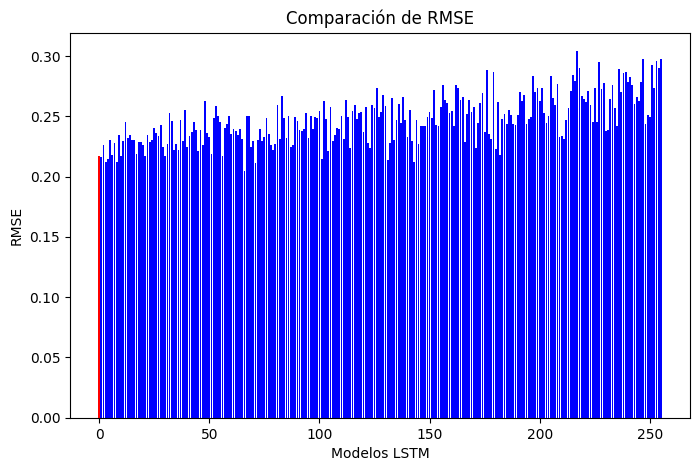

In [13]:
#Grafico
colors = ['red'] + ['blue'] * (len(lista_valores) - 1)

plt.figure(figsize=(8, 5))
plt.bar(range(len(lista_valores)), lista_valores, color=colors)

plt.xlabel("Modelos LSTM")
plt.ylabel("RMSE")
plt.title("Comparación de RMSE")
plt.savefig(ruta+"graf_rmse_var.png", dpi=300, bbox_inches='tight')

plt.show()



In [14]:
#Rmse de GDP
print(f'RMSE_GDP: {lista_valores[0]}')
print(f'Valor minimo: {min(lista_valores)}')
print(f'Valor maximo: {max(lista_valores)}')
print(f'Valor medio: {np.mean(lista_valores)}')
print(f'Desv. stndr: {np.std(lista_valores)}')

RMSE_GDP: 0.21729432046413422
Valor minimo: 0.20464670658111572
Valor maximo: 0.30406060814857483
Valor medio: 0.24753512733150274
Desv. stndr: 0.019898034451395492


In [15]:
#Imprimir mejor modelo
print(f'Mejores variables:')
for var in mejor_vars:
  print(var)

Mejores variables:
Fin_consum_govern
Fin_consum_hous
Fin_consum
GDP_cnstn_usd


##Guardar array

In [16]:
graf_lista_valores=np.array(lista_valores)

np.save(ruta+"graf_lista_valores.npy", graf_lista_valores)

##Mejores parametros

###Probamos con input_length - > 6

In [17]:
lista_valores_2=[]
mejor_val=9999999

In [18]:
#Probar algunos parametros
input_length=[6]
output_length=[3,4]

celdas_lstm=[32,64,128]
n_dropout=[0.4,0.6]
tasa_aprednizj=[5e-3,5e-5]
uni_dens=[32,64,128]
epoch=300
batch=[25,35,50]

In [19]:
for i in input_length:
  for j in output_length:
    for k in celdas_lstm:
      for l in n_dropout:
        for m in tasa_aprednizj:
          for n in uni_dens:
            for o in batch:
              #Datos
              x_total_train, y_total_train, x_total_valid, y_total_valid, x_total_test, y_total_test =preparar_pipeline(mejor_vars,i,j)

              #Modelo
              modelo, historia = entrenar_modelo_1(
                x_total_train,
                y_total_train,
                x_total_valid,
                y_total_valid,
                j,
                N_UNITS=k,
                dropout=l,
                learning_rate=m,
                dense_units=n,
                EPOCHS=epoch,
                BATCH_SIZE=o
              )

              rmse_ts = modelo.evaluate(x=x_total_valid, y=y_total_valid, verbose=0)
              print(f"Parametros:{i},{j},{k},{l},{m},{n},{o} -> loss_val: {rmse_ts}")

              lista_valores_2.append(rmse_ts)

              #Guardar los mejores parametros
              if rmse_ts<mejor_val:
                mejor_val=rmse_ts
                mejor_par=[i,j,k,l,m,n,o]
                mejor_modelo=modelo
                mejor_historia=historia

Parametros:6,3,32,0.4,0.005,32,25 -> loss_val: 0.27990835905075073
Parametros:6,3,32,0.4,0.005,32,35 -> loss_val: 0.2474551498889923
Parametros:6,3,32,0.4,0.005,32,50 -> loss_val: 0.2728297710418701
Parametros:6,3,32,0.4,0.005,64,25 -> loss_val: 0.2529982626438141
Parametros:6,3,32,0.4,0.005,64,35 -> loss_val: 0.22959265112876892
Parametros:6,3,32,0.4,0.005,64,50 -> loss_val: 0.24567165970802307
Parametros:6,3,32,0.4,0.005,128,25 -> loss_val: 0.2413558065891266
Parametros:6,3,32,0.4,0.005,128,35 -> loss_val: 0.26493746042251587
Parametros:6,3,32,0.4,0.005,128,50 -> loss_val: 0.2695331573486328
Parametros:6,3,32,0.4,5e-05,32,25 -> loss_val: 0.2981018126010895
Parametros:6,3,32,0.4,5e-05,32,35 -> loss_val: 0.29364678263664246
Parametros:6,3,32,0.4,5e-05,32,50 -> loss_val: 0.28976139426231384
Parametros:6,3,32,0.4,5e-05,64,25 -> loss_val: 0.2845560908317566
Parametros:6,3,32,0.4,5e-05,64,35 -> loss_val: 0.2870650291442871
Parametros:6,3,32,0.4,5e-05,64,50 -> loss_val: 0.28306636214256287


In [20]:
print(f'Valor minimo: {min(lista_valores_2)}')
print(f'Valor maximo: {max(lista_valores_2)}')
print(f'Valor medio: {np.mean(lista_valores_2)}')
print(f'Desv. stndr: {np.std(lista_valores_2)}')

Valor minimo: 0.20196831226348877
Valor maximo: 0.3975435495376587
Valor medio: 0.29407604280169364
Desv. stndr: 0.04832876407560967


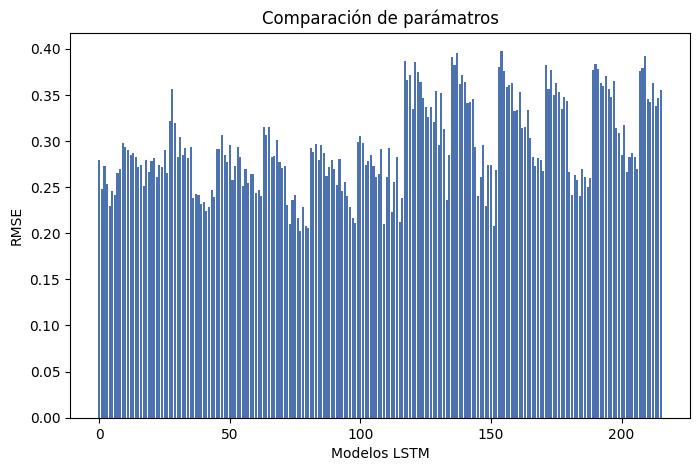

In [21]:
#Grafico
plt.figure(figsize=(8, 5))
plt.bar(range(len(lista_valores_2)), lista_valores_2, color="#4C72B0")

plt.xlabel("Modelos LSTM")
plt.ylabel("RMSE")
plt.title("Comparación de parámatros")
plt.savefig(ruta+"graf_rmse_para_6.png", dpi=300, bbox_inches='tight')

plt.show()

####Guardo array

In [22]:
graf_lista_valores_2=np.array(lista_valores_2)
np.save(ruta+"graf_lista_valores_6.npy", graf_lista_valores_2)

###Probamos con input_length - > 8

In [23]:
lista_valores_2=[]

In [24]:
#Probar algunos parametros
input_length=[8]
output_length=[3,4]

celdas_lstm=[32,64,128]
n_dropout=[0.4,0.6]
tasa_aprednizj=[5e-3,5e-5]
uni_dens=[32,64,128]
epoch=300
batch=[25,35,50]

In [25]:
for i in input_length:
  for j in output_length:
    for k in celdas_lstm:
      for l in n_dropout:
        for m in tasa_aprednizj:
          for n in uni_dens:
            for o in batch:
              #Datos
              x_total_train, y_total_train, x_total_valid, y_total_valid, x_total_test, y_total_test =preparar_pipeline(mejor_vars,i,j)

              #Modelo
              modelo, historia = entrenar_modelo_1(
                x_total_train,
                y_total_train,
                x_total_valid,
                y_total_valid,
                j,
                N_UNITS=k,
                dropout=l,
                learning_rate=m,
                dense_units=n,
                EPOCHS=epoch,
                BATCH_SIZE=o
              )

              rmse_ts = modelo.evaluate(x=x_total_valid, y=y_total_valid, verbose=0)
              print(f"Parametros:{i},{j},{k},{l},{m},{n},{o} -> loss_val: {rmse_ts}")

              lista_valores_2.append(rmse_ts)

              #Guardar los mejores parametros
              if rmse_ts<mejor_val:
                mejor_val=rmse_ts
                mejor_par=[i,j,k,l,m,n,o]
                mejor_modelo=modelo
                mejor_historia=historia

Parametros:8,3,32,0.4,0.005,32,25 -> loss_val: 0.304548978805542
Parametros:8,3,32,0.4,0.005,32,35 -> loss_val: 0.27130091190338135
Parametros:8,3,32,0.4,0.005,32,50 -> loss_val: 0.263494074344635
Parametros:8,3,32,0.4,0.005,64,25 -> loss_val: 0.26519975066185
Parametros:8,3,32,0.4,0.005,64,35 -> loss_val: 0.2579314708709717
Parametros:8,3,32,0.4,0.005,64,50 -> loss_val: 0.30306297540664673
Parametros:8,3,32,0.4,0.005,128,25 -> loss_val: 0.26771315932273865
Parametros:8,3,32,0.4,0.005,128,35 -> loss_val: 0.21802785992622375
Parametros:8,3,32,0.4,0.005,128,50 -> loss_val: 0.31032630801200867
Parametros:8,3,32,0.4,5e-05,32,25 -> loss_val: 0.3206793963909149
Parametros:8,3,32,0.4,5e-05,32,35 -> loss_val: 0.3188227415084839
Parametros:8,3,32,0.4,5e-05,32,50 -> loss_val: 0.33033061027526855
Parametros:8,3,32,0.4,5e-05,64,25 -> loss_val: 0.28619661927223206
Parametros:8,3,32,0.4,5e-05,64,35 -> loss_val: 0.2935520112514496
Parametros:8,3,32,0.4,5e-05,64,50 -> loss_val: 0.30176424980163574
Par

In [26]:
print(f'Valor minimo: {min(lista_valores_2)}')
print(f'Valor maximo: {max(lista_valores_2)}')
print(f'Valor medio: {np.mean(lista_valores_2)}')
print(f'Desv. stndr: {np.std(lista_valores_2)}')

Valor minimo: 0.18239198625087738
Valor maximo: 0.4083578586578369
Valor medio: 0.3010478293592179
Desv. stndr: 0.0500871984130594


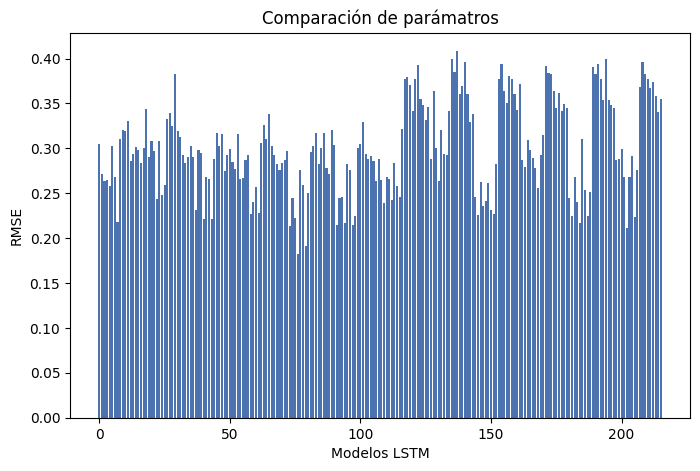

In [27]:
#Grafico
plt.figure(figsize=(8, 5))
plt.bar(range(len(lista_valores_2)), lista_valores_2, color="#4C72B0")

plt.xlabel("Modelos LSTM")
plt.ylabel("RMSE")
plt.title("Comparación de parámatros")
plt.savefig(ruta+"graf_rmse_para_8.png", dpi=300, bbox_inches='tight')

plt.show()

####Guardo array

In [28]:
graf_lista_valores_2=np.array(lista_valores_2)
np.save(ruta+"graf_lista_valores_8.npy", graf_lista_valores_2)

###Probamos con input_length - > 10

In [29]:
lista_valores_2=[]

In [30]:
#Probar algunos parametros
input_length=[10]
output_length=[3,4]

celdas_lstm=[32,64,128]
n_dropout=[0.4,0.6]
tasa_aprednizj=[5e-3,5e-5]
uni_dens=[32,64,128]
epoch=300
batch=[25,35,50]

In [31]:
for i in input_length:
  for j in output_length:
    for k in celdas_lstm:
      for l in n_dropout:
        for m in tasa_aprednizj:
          for n in uni_dens:
            for o in batch:
              #Datos
              x_total_train, y_total_train, x_total_valid, y_total_valid, x_total_test, y_total_test =preparar_pipeline(mejor_vars,i,j)

              #Modelo
              modelo, historia = entrenar_modelo_1(
                x_total_train,
                y_total_train,
                x_total_valid,
                y_total_valid,
                j,
                N_UNITS=k,
                dropout=l,
                learning_rate=m,
                dense_units=n,
                EPOCHS=epoch,
                BATCH_SIZE=o
              )

              rmse_ts = modelo.evaluate(x=x_total_valid, y=y_total_valid, verbose=0)
              print(f"Parametros:{i},{j},{k},{l},{m},{n},{o} -> loss_val: {rmse_ts}")

              lista_valores_2.append(rmse_ts)

              #Guardar los mejores parametros
              if rmse_ts<mejor_val:
                mejor_val=rmse_ts
                mejor_par=[i,j,k,l,m,n,o]
                mejor_modelo=modelo
                mejor_historia=historia

Parametros:10,3,32,0.4,0.005,32,25 -> loss_val: 0.2480907142162323
Parametros:10,3,32,0.4,0.005,32,35 -> loss_val: 0.2701185941696167
Parametros:10,3,32,0.4,0.005,32,50 -> loss_val: 0.23321940004825592
Parametros:10,3,32,0.4,0.005,64,25 -> loss_val: 0.20812225341796875
Parametros:10,3,32,0.4,0.005,64,35 -> loss_val: 0.21587572991847992
Parametros:10,3,32,0.4,0.005,64,50 -> loss_val: 0.22338612377643585
Parametros:10,3,32,0.4,0.005,128,25 -> loss_val: 0.2197924256324768
Parametros:10,3,32,0.4,0.005,128,35 -> loss_val: 0.221292182803154
Parametros:10,3,32,0.4,0.005,128,50 -> loss_val: 0.21168525516986847
Parametros:10,3,32,0.4,5e-05,32,25 -> loss_val: 0.33775794506073
Parametros:10,3,32,0.4,5e-05,32,35 -> loss_val: 0.3240443766117096
Parametros:10,3,32,0.4,5e-05,32,50 -> loss_val: 0.3148394823074341
Parametros:10,3,32,0.4,5e-05,64,25 -> loss_val: 0.3063424527645111
Parametros:10,3,32,0.4,5e-05,64,35 -> loss_val: 0.27327093482017517
Parametros:10,3,32,0.4,5e-05,64,50 -> loss_val: 0.287235

In [32]:
print(f'Valor minimo: {min(lista_valores_2)}')
print(f'Valor maximo: {max(lista_valores_2)}')
print(f'Valor medio: {np.mean(lista_valores_2)}')
print(f'Desv. stndr: {np.std(lista_valores_2)}')

Valor minimo: 0.18907293677330017
Valor maximo: 0.41573071479797363
Valor medio: 0.2814129651006725
Desv. stndr: 0.06189714580208544


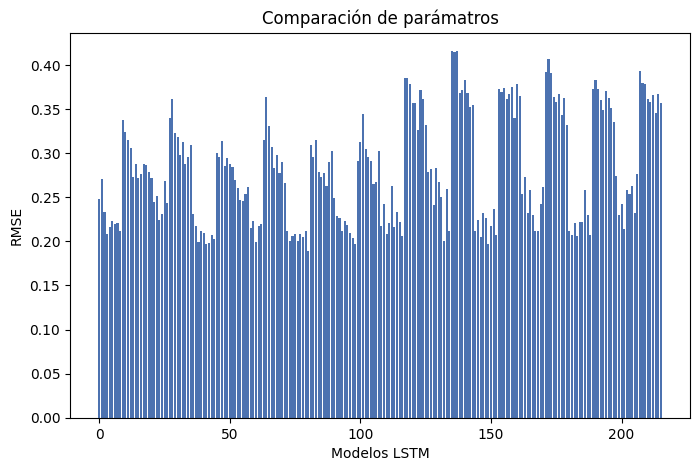

In [33]:
#Grafico
plt.figure(figsize=(8, 5))
plt.bar(range(len(lista_valores_2)), lista_valores_2, color="#4C72B0")

plt.xlabel("Modelos LSTM")
plt.ylabel("RMSE")
plt.title("Comparación de parámatros")
plt.savefig(ruta+"graf_rmse_para_10.png", dpi=300, bbox_inches='tight')

plt.show()

####Guardo array

In [34]:
graf_lista_valores_2=np.array(lista_valores_2)
np.save(ruta+"graf_lista_valores_10.npy", graf_lista_valores_2)

###Probamos con input_length - > 12

In [35]:
lista_valores_2=[]

In [36]:
#Probar algunos parametros
input_length=[12]
output_length=[3,4]

celdas_lstm=[32,64,128]
n_dropout=[0.4,0.6]
tasa_aprednizj=[5e-3,5e-5]
uni_dens=[32,64,128]
epoch=300
batch=[25,35,50]

In [37]:
for i in input_length:
  for j in output_length:
    for k in celdas_lstm:
      for l in n_dropout:
        for m in tasa_aprednizj:
          for n in uni_dens:
            for o in batch:
              #Datos
              x_total_train, y_total_train, x_total_valid, y_total_valid, x_total_test, y_total_test =preparar_pipeline(mejor_vars,i,j)

              #Modelo
              modelo, historia = entrenar_modelo_1(
                x_total_train,
                y_total_train,
                x_total_valid,
                y_total_valid,
                j,
                N_UNITS=k,
                dropout=l,
                learning_rate=m,
                dense_units=n,
                EPOCHS=epoch,
                BATCH_SIZE=o
              )

              rmse_ts = modelo.evaluate(x=x_total_valid, y=y_total_valid, verbose=0)
              print(f"Parametros:{i},{j},{k},{l},{m},{n},{o} -> loss_val: {rmse_ts}")

              lista_valores_2.append(rmse_ts)

              #Guardar los mejores parametros
              if rmse_ts<mejor_val:
                mejor_val=rmse_ts
                mejor_par=[i,j,k,l,m,n,o]
                mejor_modelo=modelo
                mejor_historia=historia

Parametros:12,3,32,0.4,0.005,32,25 -> loss_val: 0.23942352831363678
Parametros:12,3,32,0.4,0.005,32,35 -> loss_val: 0.268311470746994
Parametros:12,3,32,0.4,0.005,32,50 -> loss_val: 0.2742038071155548
Parametros:12,3,32,0.4,0.005,64,25 -> loss_val: 0.23654407262802124
Parametros:12,3,32,0.4,0.005,64,35 -> loss_val: 0.23649781942367554
Parametros:12,3,32,0.4,0.005,64,50 -> loss_val: 0.2344639152288437
Parametros:12,3,32,0.4,0.005,128,25 -> loss_val: 0.22030699253082275
Parametros:12,3,32,0.4,0.005,128,35 -> loss_val: 0.22408773005008698
Parametros:12,3,32,0.4,0.005,128,50 -> loss_val: 0.23350359499454498
Parametros:12,3,32,0.4,5e-05,32,25 -> loss_val: 0.29514721035957336
Parametros:12,3,32,0.4,5e-05,32,35 -> loss_val: 0.30838504433631897
Parametros:12,3,32,0.4,5e-05,32,50 -> loss_val: 0.3024373948574066
Parametros:12,3,32,0.4,5e-05,64,25 -> loss_val: 0.30626410245895386
Parametros:12,3,32,0.4,5e-05,64,35 -> loss_val: 0.29298144578933716
Parametros:12,3,32,0.4,5e-05,64,50 -> loss_val: 0.

In [38]:
print(f'Valor minimo: {min(lista_valores_2)}')
print(f'Valor maximo: {max(lista_valores_2)}')
print(f'Valor medio: {np.mean(lista_valores_2)}')
print(f'Desv. stndr: {np.std(lista_valores_2)}')

Valor minimo: 0.207523375749588
Valor maximo: 0.4494606554508209
Valor medio: 0.29738251657949555
Desv. stndr: 0.05182660227557139


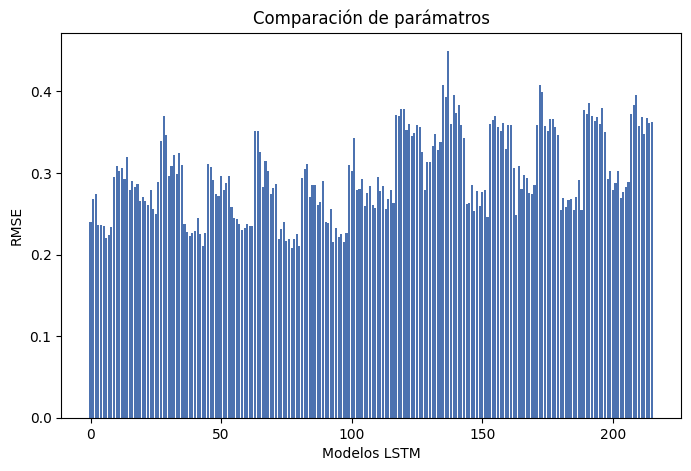

In [39]:
#Grafico
plt.figure(figsize=(8, 5))
plt.bar(range(len(lista_valores_2)), lista_valores_2, color="#4C72B0")

plt.xlabel("Modelos LSTM")
plt.ylabel("RMSE")
plt.title("Comparación de parámatros")
plt.savefig(ruta+"graf_rmse_para_12.png", dpi=300, bbox_inches='tight')

plt.show()

####Guardo array

In [40]:
graf_lista_valores_2=np.array(lista_valores_2)
np.save(ruta+"graf_lista_valores_12.npy", graf_lista_valores_2)

#Mejor modelo

In [41]:
#Mejor parametros
print(f'Mejores parametros:')
print('input_length:',mejor_par[0])
print('output_length:',mejor_par[1])
print('celdas_lstm:',mejor_par[2])
print('n_dropout:',mejor_par[3])
print('tasa_aprednizj:',mejor_par[4])
print('uni_dens:',mejor_par[5])
print('batch:',mejor_par[6])

Mejores parametros:
input_length: 8
output_length: 3
celdas_lstm: 128
n_dropout: 0.4
tasa_aprednizj: 0.005
uni_dens: 64
batch: 35


In [42]:
#Mejor modelo
print(f'Mejores parametros:')
input_length=mejor_par[0]
output_length=mejor_par[1]
celdas_lstm=mejor_par[2]
n_dropout=mejor_par[3]
tasa_aprednizj=mejor_par[4]
uni_dens=mejor_par[5]
batch=mejor_par[6]
print('input_length:',input_length)
print('output_length:',output_length)
print('celdas_lstm:',celdas_lstm)
print('n_dropout:',n_dropout)
print('tasa_aprednizj:',tasa_aprednizj)
print('uni_dens:',uni_dens)
print('batch:',batch)

#Datos
x_total_train, y_total_train, x_total_valid, y_total_valid, x_total_test, y_total_test =preparar_pipeline(mejor_vars,input_length,output_length)

#Modelo
mejor_modelo, historia = entrenar_modelo_1(
  x_total_train,
  y_total_train,
  x_total_valid,
  y_total_valid,
  output_length,
  N_UNITS=celdas_lstm,
  dropout=n_dropout,
  learning_rate=tasa_aprednizj,
  dense_units=uni_dens,
  EPOCHS=epoch,
  BATCH_SIZE=batch
)


# Cálculo de rmses para train, val y test
rmse_tr = mejor_modelo.evaluate(x=x_total_train, y=y_total_train, verbose=0)
rmse_vl = mejor_modelo.evaluate(x=x_total_valid, y=y_total_valid, verbose=0)
rmse_ts = mejor_modelo.evaluate(x=x_total_test, y=y_total_test, verbose=0)


Mejores parametros:
input_length: 8
output_length: 3
celdas_lstm: 128
n_dropout: 0.4
tasa_aprednizj: 0.005
uni_dens: 64
batch: 35


In [43]:
# Imprimir resultados en pantalla
print('\nComparativo desempeños:')
print(f'  RMSE train:\t {rmse_tr:.3f}')
print(f'  RMSE val:\t {rmse_vl:.3f}')
print(f'  RMSE test:\t {rmse_ts:.3f}')


Comparativo desempeños:
  RMSE train:	 0.104
  RMSE val:	 0.199
  RMSE test:	 0.369


#Guardar modelo

In [44]:
mejor_modelo.save(ruta+"modelo_gdp.keras")

#Guardar parametros

In [45]:
config = {
    "input_length": input_length,
    "output_length": output_length,
    "vars_keep": mejor_vars
}

with open(ruta+"config.json", "w") as f:
    json.dump(config, f)


#Guardar escaladores

In [46]:
scalers_save={}

for name in list(globals().keys()):
    if name.startswith("scaler_"):
        scalers_save[name] = globals()[name]

with open(ruta+"scalers.pkl", "wb") as f:
    pickle.dump(scalers_save, f)